# Multipole Moment Comparison for Ion Trap Geometries

Replicates **Table 3.2** -- multipole ratios $p_N/p_2$ for eight trap cross-sections.

**Method:**
1. Solve Laplace's equation on a 2-D cross-section (direct sparse solver, 501 x 501).
2. Fit the RF potential $\phi_{\mathrm{rf}}$ to a circular multipole expansion.
3. Compute the pseudopotential $\phi_{\mathrm{ps}} = \frac{q}{4m\Omega_{\mathrm{rf}}^2}(V_{\mathrm{rf}}\nabla\phi_{\mathrm{rf}})^2$.
4. Fit $\phi_{\mathrm{ps}}$ to a circular multipole expansion.
5. Report $p_N/p_2$ ratios for both.

In [1]:
# ============================================================
# Cell 1 -- Imports & physical constants
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import minimize
import time, warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

# ----- Be 9.01218 + constants -----
ION_MASS = 9.0121831 * 1.66054e-27  # kg (9Be+)
Q_E        = 1.602176634e-19  # C
V_RF_AMP   = 500.0                     # V  (peak RF amplitude)
OMEGA_RF   = 2.0 * np.pi * 30e6       # rad/s  (RF drive)

print('Setup complete.')
print(f'  Ion  : 9.0121831+, m = {ION_MASS:.4e} kg')
print(f'  RF   : V_rf = {V_RF_AMP} V, Omega/(2pi) = {OMEGA_RF/2/np.pi/1e6:.1f} MHz')

Setup complete.
  Ion  : 9.0121831+, m = 1.4965e-26 kg
  RF   : V_rf = 500.0 V, Omega/(2pi) = 30.0 MHz


In [2]:
# ============================================================
# Cell 2 -- Core solver & analysis functions
# ============================================================

def electrode_mask(cx, cy, w, h, X, Y):
    """Boolean mask for a rectangle centred at (cx, cy)."""
    return (X >= cx - w/2) & (X <= cx + w/2) & (Y >= cy - h/2) & (Y <= cy + h/2)


def solve_laplace(nx, ny, electrodes, X, Y):
    """
    Direct sparse solve of Laplace on an (nx, ny) grid.

    Boundary conditions
    -------------------
    * Electrode pixels : V = electrode voltage  (Dirichlet)
    * Domain boundary  : V = 0                  (grounded enclosure)
    * Interior         : 5-point Laplacian = 0

    Returns  V, electrodes (with 'mask' key added), fixed_mask
    """
    N = nx * ny

    fixed   = np.zeros((ny, nx), dtype=bool)
    v_map   = np.zeros((ny, nx))
    for e in electrodes:
        m = electrode_mask(e['cx'], e['cy'], e['w'], e['h'], X, Y)
        e['mask'] = m
        fixed[m]  = True
        v_map[m]  = e['V']

    # domain-boundary flag
    bnd = np.zeros((ny, nx), dtype=bool)
    bnd[0, :] = bnd[-1, :] = bnd[:, 0] = bnd[:, -1] = True

    idx  = np.arange(N)
    flat_fixed = fixed.ravel()
    flat_bnd   = bnd.ravel()
    interior   = ~flat_fixed & ~flat_bnd

    rows, cols, vals = [], [], []
    b = np.zeros(N)

    # fixed (electrode) pixels
    fi = idx[flat_fixed]
    rows.append(fi); cols.append(fi); vals.append(np.ones(len(fi)))
    b[fi] = v_map.ravel()[fi]

    # boundary (non-electrode)
    bi = idx[flat_bnd & ~flat_fixed]
    rows.append(bi); cols.append(bi); vals.append(np.ones(len(bi)))
    # b already 0

    # interior -- 5-point stencil
    ii = idx[interior]
    ni = len(ii)
    rows.append(ii); cols.append(ii);      vals.append(-4.0 * np.ones(ni))
    rows.append(ii); cols.append(ii - 1);  vals.append(np.ones(ni))   # left
    rows.append(ii); cols.append(ii + 1);  vals.append(np.ones(ni))   # right
    rows.append(ii); cols.append(ii - nx); vals.append(np.ones(ni))   # down
    rows.append(ii); cols.append(ii + nx); vals.append(np.ones(ni))   # up

    A = csr_matrix((np.concatenate(vals),
                     (np.concatenate(rows), np.concatenate(cols))),
                    shape=(N, N))
    V = spsolve(A, b).reshape((ny, nx))
    return V, electrodes, fixed


# ---------- RF-null finder ----------

def find_rf_null(V, X, Y, guess_y=0.0):
    """
    Locate the RF null = saddle point of phi_rf where |grad phi_rf| is
    minimised.  For symmetric traps (guess_y==0) the null is at the origin;
    for surface traps we search above the electrode plane.

    Strategy for surface traps:
      1. Evaluate phi_rf along x=0 (or near geometric centre).
      2. Find y where d(phi)/dy changes sign above the surface -- this is
         the saddle-point height.
      3. Refine with Nelder-Mead in a tight box.

    Returns (x0, y0, |grad| at null).
    """
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]
    gY, gX = np.gradient(V, dy, dx)
    gmag = np.hypot(gX, gY)

    if guess_y <= 0:
        return 0.0, 0.0, float(gmag[gmag.shape[0]//2, gmag.shape[1]//2])

    # --- surface-trap path ---
    # 1) Find saddle height along the y-column closest to x = 0
    jx = np.argmin(np.abs(X[0, :]))          # column index for x ~ 0
    col = V[:, jx]                            # phi_rf(y) at x=0
    y1d = Y[:, 0]
    above = y1d > guess_y * 0.15              # above the electrode surface
    # saddle = local max of phi along y at x=0  (Laplace => saddle, not true max)
    dcol = np.diff(col)
    candidates = np.where(above[1:-1] & (dcol[:-1] > 0) & (dcol[1:] <= 0))[0] + 1
    if len(candidates) > 0:
        # pick the one nearest to guess_y
        best = candidates[np.argmin(np.abs(y1d[candidates] - guess_y))]
        y0 = float(y1d[best])
    else:
        y0 = guess_y
    x0 = 0.0

    # 2) Grid search for min |grad| in a tight box around (x0, y0)
    box_r = max(guess_y, 30.0)
    ok = ((np.abs(X - x0) < box_r) & (np.abs(Y - y0) < box_r)
          & (Y > guess_y * 0.1))
    m = 5
    ok[:m, :] = ok[-m:, :] = ok[:, :m] = ok[:, -m:] = False

    tmp = gmag.copy();  tmp[~ok] = np.inf
    ji = np.unravel_index(tmp.argmin(), tmp.shape)
    x0, y0 = float(X[ji]), float(Y[ji])

    # 3) Nelder-Mead refinement
    interp = RegularGridInterpolator((Y[:, 0], X[0, :]), gmag,
                                     method='cubic',
                                     bounds_error=False, fill_value=np.inf)

    def _obj(xy):
        val = interp(np.array([[xy[1], xy[0]]]))
        return float(val[0])

    res = minimize(_obj, x0=[x0, y0], method='Nelder-Mead',
                   options={'xatol': dx/10, 'fatol': 1e-14, 'maxiter': 800})
    return float(res.x[0]), float(res.x[1]), float(res.fun)


# ---------- pseudopotential ----------

def pseudopotential(V_rf, X, Y,
                    Vamp=V_RF_AMP, omega=OMEGA_RF,
                    mass=ION_MASS, charge=Q_E):
    """
    phi_ps  =  q / (4 m Omega^2)  *  (V_rf |grad phi_rf|)^2

    V_rf is the Laplace solution with RF electrode(s) at 1 V;
    coordinates in microns.
    Returns phi_ps in volts.
    """
    dx_m = (X[0, 1] - X[0, 0]) * 1e-6
    dy_m = (Y[1, 0] - Y[0, 0]) * 1e-6
    gY, gX = np.gradient(V_rf, dy_m, dx_m)          # 1/m
    grad2  = Vamp**2 * (gX**2 + gY**2)              # (V/m)^2
    return charge / (4.0 * mass * omega**2) * grad2  # V


# ---------- circular Fourier multipole fit ----------

def fit_multipoles(V, X, Y, x0, y0, r_fit, R_norm,
                   n_max=8, n_theta=512):
    """
    Fourier-analyse V on a circle of radius *r_fit* centred at (x0, y0).

    Multipole convention
    --------------------
        V(r, theta) = sum_n  p_n (r / R)^n  cos(n theta - delta_n)

    Returns dict  {n: p_n}  for n = 0 .. n_max.
    """
    interp = RegularGridInterpolator((Y[:, 0], X[0, :]), V,
                                     method='cubic',
                                     bounds_error=False, fill_value=0.0)
    theta = np.linspace(0, 2*np.pi, n_theta, endpoint=False)
    pts   = np.column_stack([y0 + r_fit*np.sin(theta),
                             x0 + r_fit*np.cos(theta)])
    Vc = interp(pts)

    fft = np.fft.fft(Vc) / n_theta
    p = {}
    for n in range(n_max + 1):
        if n == 0:
            An, Bn = np.real(fft[0]), 0.0
        else:
            An =  2.0 * np.real(fft[n])
            Bn = -2.0 * np.imag(fft[n])
        amp   = np.hypot(An, Bn)                   # Fourier amplitude at r_fit
        scale = (r_fit / R_norm)**n if n > 0 else 1.0
        p[n]  = amp / scale                        # normalised coefficient
    return p


def ratio_row(p, base=2, hi=8):
    """p_n / p_base  for n = base+1 .. hi."""
    p2 = p.get(base, 0.0)
    return {f'p{n}/p{base}': (p[n]/p2 if p2 else np.nan)
            for n in range(base+1, hi+1)}


def ion_electrode_dist(elecs, x0, y0):
    """Min distance from (x0,y0) to nearest electrode surface."""
    d = np.inf
    for e in elecs:
        cx, cy, w, h = e['cx'], e['cy'], e['w'], e['h']
        px = np.clip(x0, cx - w/2, cx + w/2)
        py = np.clip(y0, cy - h/2, cy + h/2)
        d  = min(d, np.hypot(px - x0, py - y0))
    return d


print('Core functions loaded.')

Core functions loaded.


In [3]:
# ============================================================
# Cell 3 -- Trap geometry builders
# ============================================================
#
# Each builder returns  (electrodes_list, ion_height_guess).
# Electrode dict keys:  cx, cy, w, h, V, label
#
# Traps (a)-(c): symmetric quadrupole  (+1 / -1 on diagonals)
# Traps (d)-(h): RF electrodes all at +1 V, GND at 0 V
# ============================================================

def trap_a_2layer():
    """(a) 2-layer  -- 4 electrodes at corners, +/-1 V diagonal."""
    hg, vg, tw, th = 200, 200, 125, 150
    xp = hg/2 + tw/2;  yp = vg/2 + th/2
    return [
        {'cx': -xp, 'cy':  yp, 'w': tw, 'h': th, 'V': -1.0, 'label': 'RF-'},
        {'cx':  xp, 'cy':  yp, 'w': tw, 'h': th, 'V':  1.0, 'label': 'RF+'},
        {'cx': -xp, 'cy': -yp, 'w': tw, 'h': th, 'V':  1.0, 'label': 'RF+'},
        {'cx':  xp, 'cy': -yp, 'w': tw, 'h': th, 'V': -1.0, 'label': 'RF-'},
    ], 0.0


def trap_b_balanced():
    """(b) Balanced 2-layer  -- same as (a) but vg = 220 um."""
    hg, vg, tw, th = 200, 220, 125, 150
    xp = hg/2 + tw/2;  yp = vg/2 + th/2
    return [
        {'cx': -xp, 'cy':  yp, 'w': tw, 'h': th, 'V': -1.0, 'label': 'RF-'},
        {'cx':  xp, 'cy':  yp, 'w': tw, 'h': th, 'V':  1.0, 'label': 'RF+'},
        {'cx': -xp, 'cy': -yp, 'w': tw, 'h': th, 'V':  1.0, 'label': 'RF+'},
        {'cx':  xp, 'cy': -yp, 'w': tw, 'h': th, 'V': -1.0, 'label': 'RF-'},
    ], 0.0


def trap_c_3layer():
    """(c) 3-layer  -- top/bottom vs left/right, +1/-1."""
    hg, vg, rft = 200, 250, 125
    return [
        {'cx': 0,             'cy':  vg/2, 'w': 300, 'h': 100, 'V':  1.0, 'label': 'V+'},
        {'cx': 0,             'cy': -vg/2, 'w': 300, 'h': 100, 'V':  1.0, 'label': 'V+'},
        {'cx': -hg/2-rft/2,   'cy': 0,     'w': rft, 'h': 150, 'V': -1.0, 'label': 'V-'},
        {'cx':  hg/2+rft/2,   'cy': 0,     'w': rft, 'h': 150, 'V': -1.0, 'label': 'V-'},
    ], 0.0


def trap_d_algaas():
    """
    (d) GaAs/AlGaAs 2-layer  -- two stacked electrode pairs.
    Left stack: GND-top / RF-bottom.   Right stack: RF-top / GND-bottom.
    RF electrodes at +1 V, GND at 0 V.
    """
    hg, vg, t, ew = 60, 4, 10, 50
    xl = -(hg/2 + ew/2);  xr = hg/2 + ew/2
    yt =  vg/2 + t/2;     yb = -(vg/2 + t/2)
    return [
        {'cx': xl, 'cy': yt, 'w': ew, 'h': t, 'V': 0.0, 'label': 'GND'},
        {'cx': xl, 'cy': yb, 'w': ew, 'h': t, 'V': 1.0, 'label': 'RF'},
        {'cx': xr, 'cy': yt, 'w': ew, 'h': t, 'V': 1.0, 'label': 'RF'},
        {'cx': xr, 'cy': yb, 'w': ew, 'h': t, 'V': 0.0, 'label': 'GND'},
    ], 0.0


def trap_e_inplane4():
    """
    (e) In-plane 4-wire  -- GND | RF | gap | RF | GND
    Both RF at +1 V, GND at 0 V.  Ion at 40 um above plane.
    """
    gap, t, rfw, gw = 80, 20, 60, 100
    return [
        {'cx': -(gap/2+rfw+gw/2), 'cy': 0, 'w': gw,  'h': t, 'V': 0.0, 'label': 'GND'},
        {'cx': -(gap/2+rfw/2),    'cy': 0, 'w': rfw,  'h': t, 'V': 1.0, 'label': 'RF'},
        {'cx':  (gap/2+rfw/2),    'cy': 0, 'w': rfw,  'h': t, 'V': 1.0, 'label': 'RF'},
        {'cx':  (gap/2+rfw+gw/2), 'cy': 0, 'w': gw,  'h': t, 'V': 0.0, 'label': 'GND'},
    ], 40.0


def trap_f_4wire_surface():
    """
    (f) 4-wire surface  -- GND | RF | GND | RF  (all in one plane).
    Both RF at +1 V, GND at 0 V.  Ion ~40 um above.
    """
    t = 20;  sp = 10
    gw1, rfw1, gw2, rfw2 = 80, 40, 40, 80
    x = -(gw1 + rfw1 + gw2 + rfw2 + 3*sp) / 2
    elecs = []
    for w, v, lab in [(gw1,0,'GND'),(rfw1,1,'RF'),(gw2,0,'GND'),(rfw2,1,'RF')]:
        elecs.append({'cx': x + w/2, 'cy': 0, 'w': w, 'h': t, 'V': float(v), 'label': lab})
        x += w + sp
    return elecs, 40.0


def trap_g_5wire_symm():
    """
    (g) 5-wire symmetric surface -- GND | RF | GND | RF | GND.
    Both RF at +1 V.  Ion ~40 um above centre GND.
    """
    t, sp, cw, ow = 20, 10, 40, 80
    tw = 2*ow + 3*cw + 4*sp
    x  = -tw / 2
    layout = [(ow,0,'GND'),(cw,1,'RF'),(cw,0,'GND'),(cw,1,'RF'),(ow,0,'GND')]
    elecs = []
    for w, v, lab in layout:
        elecs.append({'cx': x+w/2, 'cy': 0, 'w': w, 'h': t, 'V': float(v), 'label': lab})
        x += w + sp
    return elecs, 40.0


def trap_h_5wire_asymm():
    """
    (h) 5-wire asymmetric surface -- GND | RF(44) | GND | RF(36) | GND.
    Both RF at +1 V.  Ion ~40 um above.
    """
    t, sp, cw, ow = 20, 10, 40, 80
    lrf, rrf = 44, 36
    tw = 2*ow + lrf + rrf + cw + 4*sp
    x  = -tw / 2
    layout = [(ow,0,'GND'),(lrf,1,'RF'),(cw,0,'GND'),(rrf,1,'RF'),(ow,0,'GND')]
    elecs = []
    for w, v, lab in layout:
        elecs.append({'cx': x+w/2, 'cy': 0, 'w': w, 'h': t, 'V': float(v), 'label': lab})
        x += w + sp
    return elecs, 40.0


print('8 trap builders defined.')

8 trap builders defined.


In [4]:
# ============================================================
# Custom Electrode Geometry (Rectangular + Curved Hybrid)
# ============================================================

import numpy as np

def build_trap_custom(X, Y, params):
    """
    Custom trap matching your sketch:
    - Two RF electrodes (left/right, ±V)
    - Bottom electrode (ground/DC)
    - Optional curvature to mimic hyperbolic electrodes
    """

    gap   = params[0]  # distance between inner faces (µm)
    h     = params[1]  # electrode height
    w     = params[2]  # electrode width
    b_h   = params[3]  # bottom electrode thickness
    curve = params[4]  # curvature strength (0 = rectangular)

    V = np.zeros_like(X)

    # =========================
    # LEFT RF electrode (+V)
    # =========================
    x_left = -(gap/2 + w/2)

    if curve == 0:
        left_mask = (
            (X > x_left - w/2) &
            (X < x_left + w/2) &
            (Y > -h/2) &
            (Y < h/2)
        )
    else:
        # curved inner edge
        left_mask = (
            (X > x_left - w/2) &
            (X < x_left + w/2 + curve * (Y**2)/h) &
            (Y > -h/2) &
            (Y < h/2)
        )

    V[left_mask] = +1.0


    # =========================
    # RIGHT RF electrode (-V)
    # =========================
    x_right = +(gap/2 + w/2)

    if curve == 0:
        right_mask = (
            (X > x_right - w/2) &
            (X < x_right + w/2) &
            (Y > -h/2) &
            (Y < h/2)
        )
    else:
        right_mask = (
            (X > x_right - w/2 - curve * (Y**2)/h) &
            (X < x_right + w/2) &
            (Y > -h/2) &
            (Y < h/2)
        )

    V[right_mask] = -1.0


    # =========================
    # BOTTOM electrode (ground/DC)
    # =========================
    bottom_mask = (
        (Y < -h/2) &
        (Y > -h/2 - b_h)
    )

    V[bottom_mask] = 0.0

    return V

In [5]:
# ============================================================
# Cell 4 -- simulate_trap  (main driver)
# ============================================================

def simulate_trap(builder, name, grid=501, dom_scale=1.0, plot=True):
    """
    Full pipeline for one trap geometry.

    Returns dict with keys
        rf_ratios, ps_ratios        -- p_n/p_2 dicts
        rf_p, ps_p                  -- raw multipole amplitudes
        is_surface                  -- whether the trap is a surface trap
    """
    t0 = time.time()
    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')

    # ---- electrode list ----
    elecs, ion_y_guess = builder()
    is_surface = (ion_y_guess > 0)

    # ---- domain size from electrode extent ----
    max_x = max(abs(e['cx']) + e['w']/2 for e in elecs)
    max_y = max(abs(e['cy']) + e['h']/2 for e in elecs)
    ds = max(max_x, max_y) * dom_scale + 100

    nx = ny = grid
    x = np.linspace(-ds, ds, nx)
    y = np.linspace(-ds, ds, ny)
    X, Y = np.meshgrid(x, y)
    dx = x[1] - x[0]
    print(f'  grid {nx}x{ny}  domain +/-{ds:.0f} um  dx={dx:.2f} um')

    # ---- solve Laplace (direct sparse) ----
    V_rf, elecs, fixed = solve_laplace(nx, ny, elecs, X, Y)
    print(f'  Laplace solved in {time.time()-t0:.1f} s')

    # ---- ion position ----
    if not is_surface:
        ix, iy = 0.0, 0.0
        print(f'  ion at origin (by symmetry)')
    else:
        ix, iy, gn = find_rf_null(V_rf, X, Y, ion_y_guess)
        print(f'  RF null at ({ix:.2f}, {iy:.2f})  |grad|={gn:.3e}')

    # ---- fitting parameters ----
    R = ion_electrode_dist(elecs, ix, iy)
    r_fit = R * 0.6
    r_fit = max(r_fit, 3*dx)
    R     = max(R, r_fit)
    print(f'  R={R:.2f} um   r_fit={r_fit:.2f} um')

    # ---- fit phi_rf ----
    rf_p = fit_multipoles(V_rf, X, Y, ix, iy, r_fit, R)
    rf_rat = ratio_row(rf_p)
    print(f'  phi_rf  p2={rf_p[2]:.4e}')
    for k, v in rf_rat.items():
        print(f'    {k} = {v:.4f}')

    # ---- pseudopotential ----
    phi_ps = pseudopotential(V_rf, X, Y)
    ps_p   = fit_multipoles(phi_ps, X, Y, ix, iy, r_fit, R)
    ps_rat = ratio_row(ps_p)

    # For symmetric traps the pseudopotential is nearly radially
    # symmetric near the origin (phi_ps ~ r^2), so the n=2 Fourier
    # component is just a cross-term artefact and ratios are meaningless.
    ps_ok = is_surface
    if not ps_ok:
        ps_rat = {k: np.nan for k in ps_rat}
        print(f'  phi_ps  p2 ~ 0  (radially symmetric -- ratios N/A)')
    else:
        print(f'  phi_ps  p2={ps_p[2]:.4e}')
        for k, v in ps_rat.items():
            print(f'    {k} = {v:.4f}')

    # ---- plot ----
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # phi_rf
        ax = axes[0]
        vm = max(abs(V_rf.min()), abs(V_rf.max()))
        im = ax.imshow(V_rf, extent=[x[0],x[-1],y[0],y[-1]],
                       origin='lower', cmap='RdBu_r', vmin=-vm, vmax=vm)
        fig.colorbar(im, ax=ax, label='phi_rf (V)', shrink=0.85)
        for e in elecs:
            ax.contour(X, Y, e['mask'].astype(float), [0.5],
                       colors='k', linewidths=0.8)
        th = np.linspace(0, 2*np.pi, 200)
        ax.plot(ix+r_fit*np.cos(th), iy+r_fit*np.sin(th), 'g--', lw=0.8)
        ax.plot(ix, iy, 'r+', ms=10, mew=2)
        ax.set(title=f'{name} -- phi_rf',
               xlabel='x (um)', ylabel='y (um)', aspect='equal')

        # phi_ps (zoomed)
        ax = axes[1]
        zoom = R * 3
        xi = np.searchsorted(x, ix);  yi = np.searchsorted(y, iy)
        mp = int(zoom / dx)
        s = np.s_[max(0,yi-mp):min(ny,yi+mp),
                  max(0,xi-mp):min(nx,xi+mp)]
        ps_z = phi_ps[s]
        ext = [X[0, max(0,s[1].start)], X[0, min(s[1].stop, nx)-1],
               Y[max(0,s[0].start), 0], Y[min(s[0].stop, ny)-1, 0]]
        im2 = ax.imshow(ps_z, extent=ext, origin='lower', cmap='viridis')
        fig.colorbar(im2, ax=ax, label='phi_ps (V)', shrink=0.85)
        ax.plot(ix, iy, 'r+', ms=10, mew=2)
        ax.plot(ix+r_fit*np.cos(th), iy+r_fit*np.sin(th), 'g--', lw=0.8)
        ax.set(title=f'{name} -- pseudopotential',
               xlabel='x (um)', ylabel='y (um)', aspect='equal')

        plt.tight_layout()
        plt.show()

    print(f'  done ({time.time()-t0:.1f} s)')
    return {'rf_ratios': rf_rat, 'ps_ratios': ps_rat,
            'rf_p': rf_p, 'ps_p': ps_p, 'is_surface': is_surface}


print('simulate_trap loaded.')

simulate_trap loaded.


  SOR converged in 784 iterations (residual 9.95e-07)
  Solved in 80.2 s

=== RESULTS ===
  p2 = 2.5085e-05
  p3/p2 = 3047.6429
  p4/p2 = 0.0023
  p5/p2 = 328.2950
  p6/p2 = 0.0448
  p7/p2 = 321.0461
  p8/p2 = 0.0127

  Pseudopotential p2 = 7.6240e+02
  p3/p2 = 0.0000
  p4/p2 = 0.1914
  p5/p2 = 0.0000
  p6/p2 = 0.2501
  p7/p2 = 0.0000
  p8/p2 = 0.0349


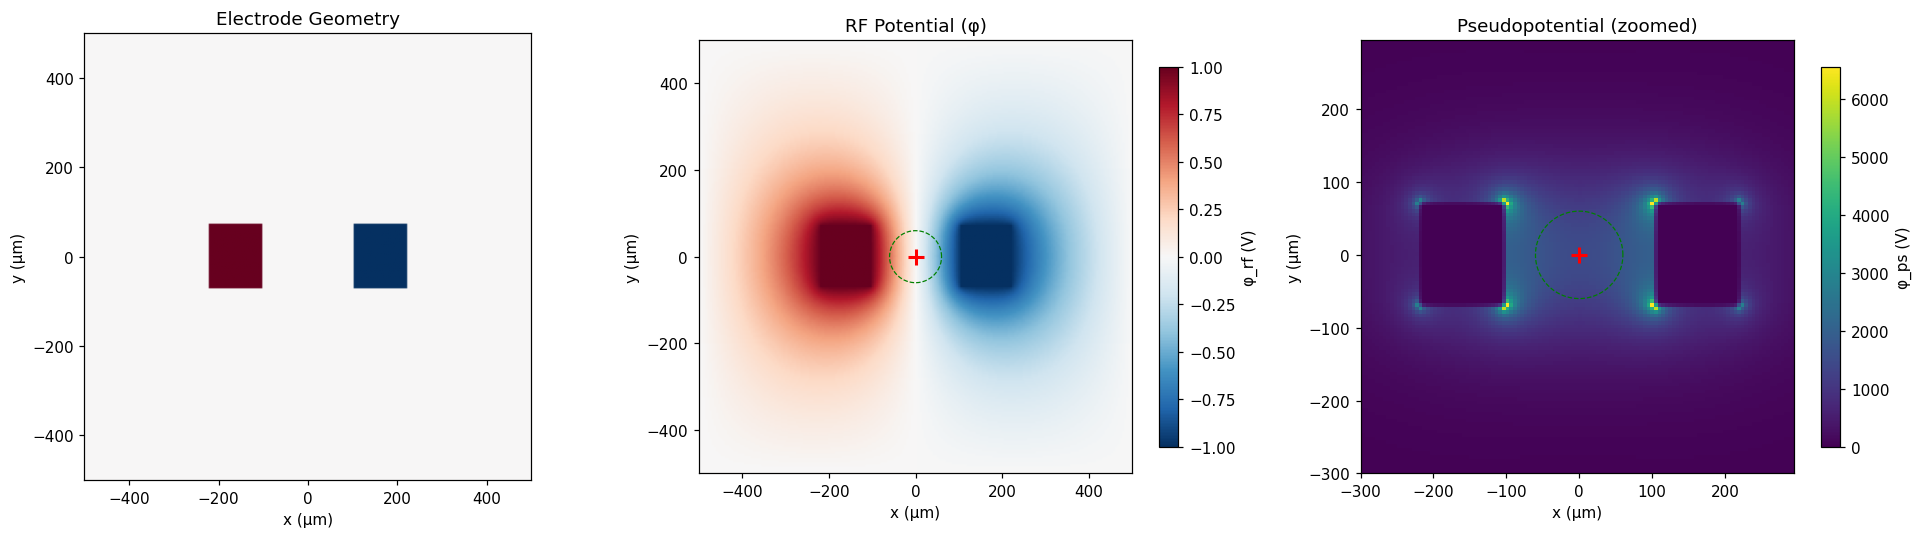

In [6]:
# ============================================================
# Run Custom Geometry: Laplace solve + Multipole Analysis
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


def solve_laplace_mask(V_mask, tol=1e-6, max_iter=20000):
    """
    Solve Laplace via SOR on a grid where non-zero pixels in V_mask
    are treated as fixed (Dirichlet) electrodes, domain boundary is
    grounded, and interior satisfies nabla^2 phi = 0.
    """
    ny, nx = V_mask.shape
    fixed = V_mask != 0
    bnd = np.zeros_like(fixed)
    bnd[0, :] = bnd[-1, :] = bnd[:, 0] = bnd[:, -1] = True

    phi = V_mask.copy().astype(float)
    phi[bnd & ~fixed] = 0.0

    omega = 1.85
    for it in range(max_iter):
        phi_old = phi.copy()
        for j in range(1, ny - 1):
            for i in range(1, nx - 1):
                if fixed[j, i] or bnd[j, i]:
                    continue
                gs = 0.25 * (phi[j, i-1] + phi[j, i+1]
                             + phi[j-1, i] + phi[j+1, i])
                phi[j, i] += omega * (gs - phi[j, i])
        diff = np.max(np.abs(phi - phi_old))
        if diff < tol:
            print(f'  SOR converged in {it+1} iterations (residual {diff:.2e})')
            break
    else:
        print(f'  SOR did not converge after {max_iter} iters (residual {diff:.2e})')
    return phi


# =========================
# Grid & parameters
# =========================
grid_size = 201
extent = 500  # µm

x = np.linspace(-extent, extent, grid_size)
y = np.linspace(-extent, extent, grid_size)
X, Y = np.meshgrid(x, y)

# =========================
# Parameters
# =========================
params = [200, 150, 125, 50, 0.0]
# [gap, height, width, bottom_height, curvature]

# =========================
# Build geometry
# =========================
V = build_trap_custom(X, Y, params)

# =========================
# Solve Laplace (mask-based SOR)
# =========================
t0 = time.time()
phi = solve_laplace_mask(V)
print(f'  Solved in {time.time()-t0:.1f} s')

# =========================
# Multipole analysis (reuses notebook functions)
# =========================
ix, iy = 0.0, 0.0
gap = params[0]
R = gap / 2.0
r_fit = R * 0.6
dx = x[1] - x[0]
r_fit = max(r_fit, 3 * dx)
R = max(R, r_fit)

rf_p = fit_multipoles(phi, X, Y, ix, iy, r_fit, R)
rf_rat = ratio_row(rf_p)

print(f'\n=== RESULTS ===')
print(f'  p2 = {rf_p[2]:.4e}')
for k, v in rf_rat.items():
    print(f'  {k} = {v:.4f}')

# =========================
# Pseudopotential
# =========================
phi_ps = pseudopotential(phi, X, Y)
ps_p = fit_multipoles(phi_ps, X, Y, ix, iy, r_fit, R)
ps_rat = ratio_row(ps_p)
print(f'\n  Pseudopotential p2 = {ps_p[2]:.4e}')
for k, v in ps_rat.items():
    print(f'  {k} = {v:.4f}')

# =========================
# Visualization
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.imshow(V, extent=[-extent, extent, -extent, extent], origin='lower', cmap='RdBu_r')
ax.set_title("Electrode Geometry")
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
ax.set_aspect('equal')

ax = axes[1]
vm = max(abs(phi.min()), abs(phi.max()))
im = ax.imshow(phi, extent=[-extent, extent, -extent, extent],
               origin='lower', cmap='RdBu_r', vmin=-vm, vmax=vm)
fig.colorbar(im, ax=ax, label='φ_rf (V)', shrink=0.85)
th = np.linspace(0, 2*np.pi, 200)
ax.plot(ix + r_fit*np.cos(th), iy + r_fit*np.sin(th), 'g--', lw=0.8)
ax.plot(ix, iy, 'r+', ms=10, mew=2)
ax.set_title("RF Potential (φ)")
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
ax.set_aspect('equal')

ax = axes[2]
zoom = R * 3
xi_idx = np.searchsorted(x, ix); yi_idx = np.searchsorted(y, iy)
mp = int(zoom / dx)
s = np.s_[max(0, yi_idx-mp):min(grid_size, yi_idx+mp),
          max(0, xi_idx-mp):min(grid_size, xi_idx+mp)]
ps_z = phi_ps[s]
ext_z = [X[0, max(0, s[1].start)], X[0, min(s[1].stop, grid_size)-1],
         Y[max(0, s[0].start), 0], Y[min(s[0].stop, grid_size)-1, 0]]
im2 = ax.imshow(ps_z, extent=ext_z, origin='lower', cmap='viridis')
fig.colorbar(im2, ax=ax, label='φ_ps (V)', shrink=0.85)
ax.plot(ix + r_fit*np.cos(th), iy + r_fit*np.sin(th), 'g--', lw=0.8)
ax.plot(ix, iy, 'r+', ms=10, mew=2)
ax.set_title("Pseudopotential (zoomed)")
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
ax.set_aspect('equal')

plt.tight_layout()
plt.show()


  (a) 2-layer
  grid 501x501  domain +/-600 um  dx=2.40 um
  Laplace solved in 3.0 s
  ion at origin (by symmetry)
  R=141.42 um   r_fit=84.85 um
  phi_rf  p2=7.7134e-01
    p3/p2 = 0.0000
    p4/p2 = 0.0018
    p5/p2 = 0.0000
    p6/p2 = 0.1028
    p7/p2 = 0.0000
    p8/p2 = 0.0005
  phi_ps  p2 ~ 0  (radially symmetric -- ratios N/A)


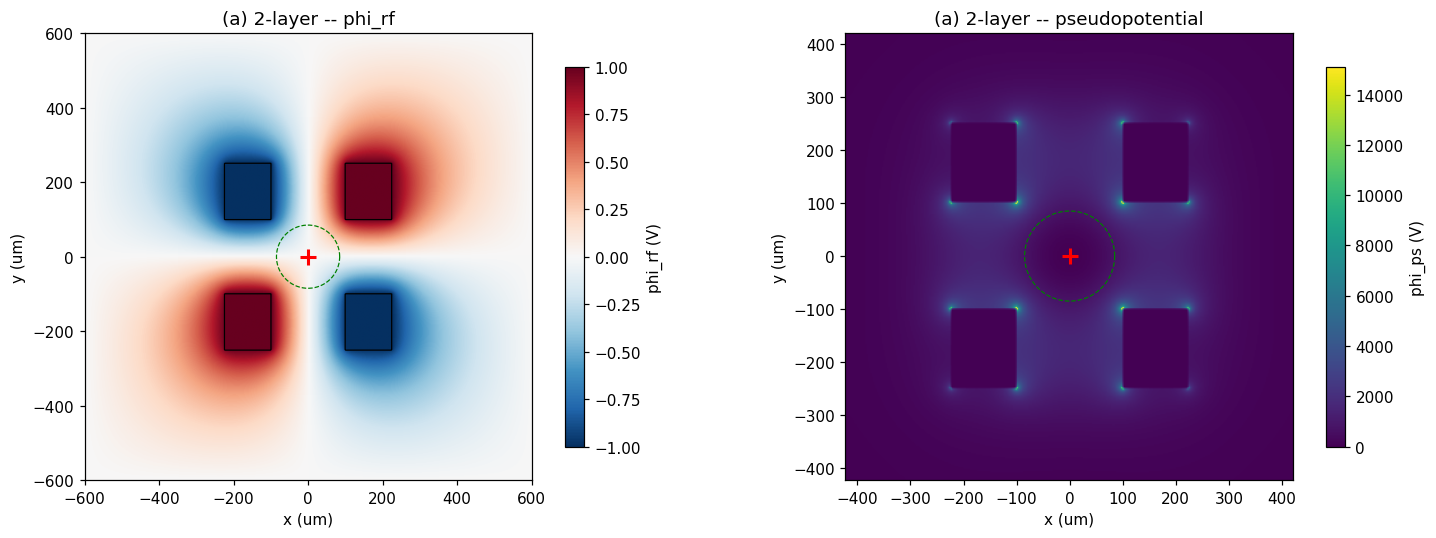

  done (4.7 s)

  (b) Balanced 2-layer
  grid 501x501  domain +/-620 um  dx=2.48 um
  Laplace solved in 3.1 s
  ion at origin (by symmetry)
  R=148.66 um   r_fit=89.20 um
  phi_rf  p2=7.5836e-01
    p3/p2 = 0.0000
    p4/p2 = 0.0413
    p5/p2 = 0.0000
    p6/p2 = 0.0982
    p7/p2 = 0.0000
    p8/p2 = 0.0191
  phi_ps  p2 ~ 0  (radially symmetric -- ratios N/A)


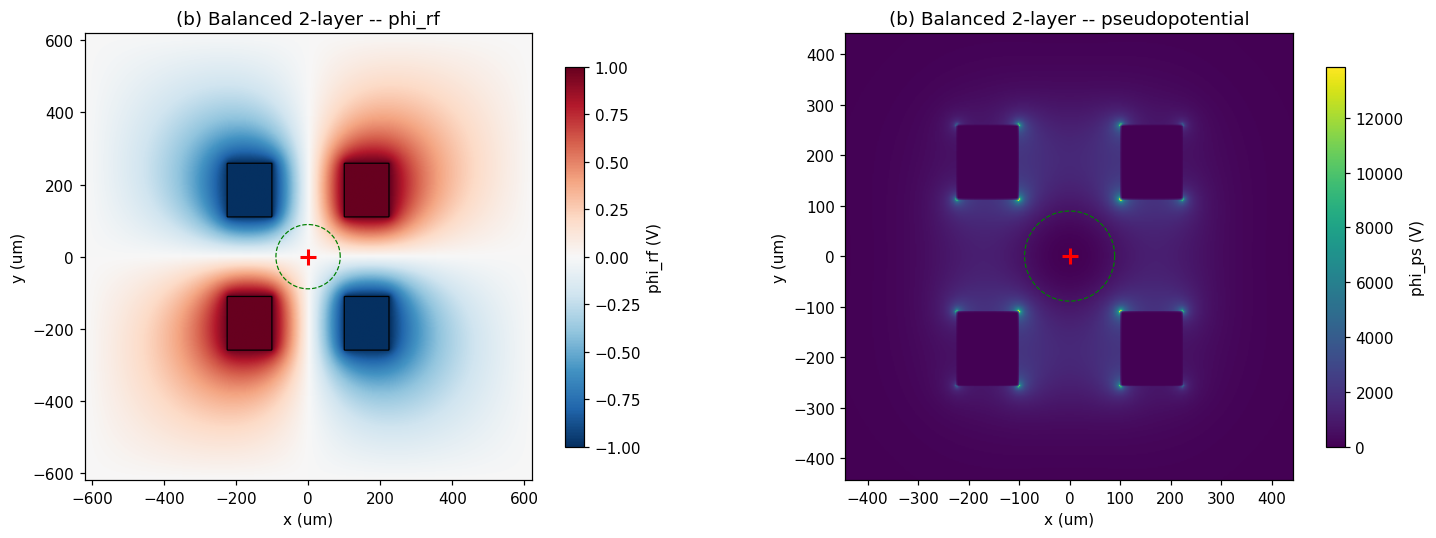

  done (4.7 s)

  (c) 3-layer
  grid 501x501  domain +/-775 um  dx=3.10 um
  Laplace solved in 3.3 s
  ion at origin (by symmetry)
  R=75.00 um   r_fit=45.00 um
  phi_rf  p2=6.9394e-01
    p3/p2 = 0.0000
    p4/p2 = 0.1202
    p5/p2 = 0.0000
    p6/p2 = 0.0338
    p7/p2 = 0.0000
    p8/p2 = 0.0109
  phi_ps  p2 ~ 0  (radially symmetric -- ratios N/A)


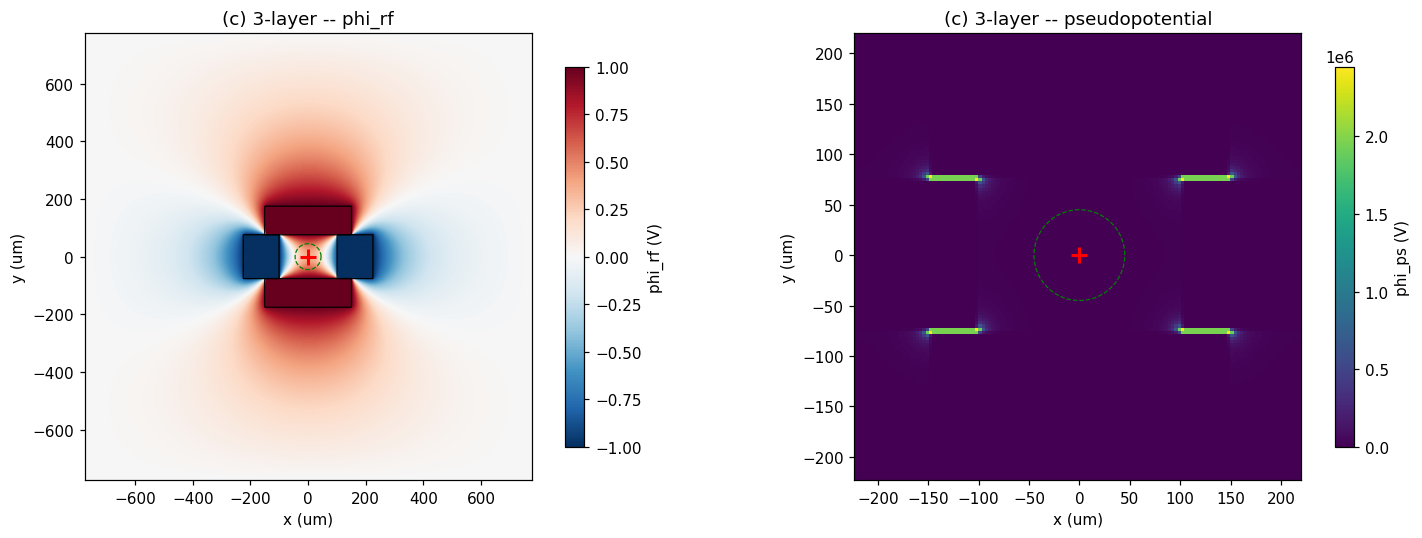

  done (4.8 s)

  (d) 2-layer AlGaAs
  grid 501x501  domain +/-300 um  dx=1.20 um
  Laplace solved in 3.7 s
  ion at origin (by symmetry)
  R=30.07 um   r_fit=18.04 um
  phi_rf  p2=2.9231e-01
    p3/p2 = 0.0000
    p4/p2 = 0.6225
    p5/p2 = 0.0000
    p6/p2 = 0.4225
    p7/p2 = 0.0000
    p8/p2 = 0.2954
  phi_ps  p2 ~ 0  (radially symmetric -- ratios N/A)


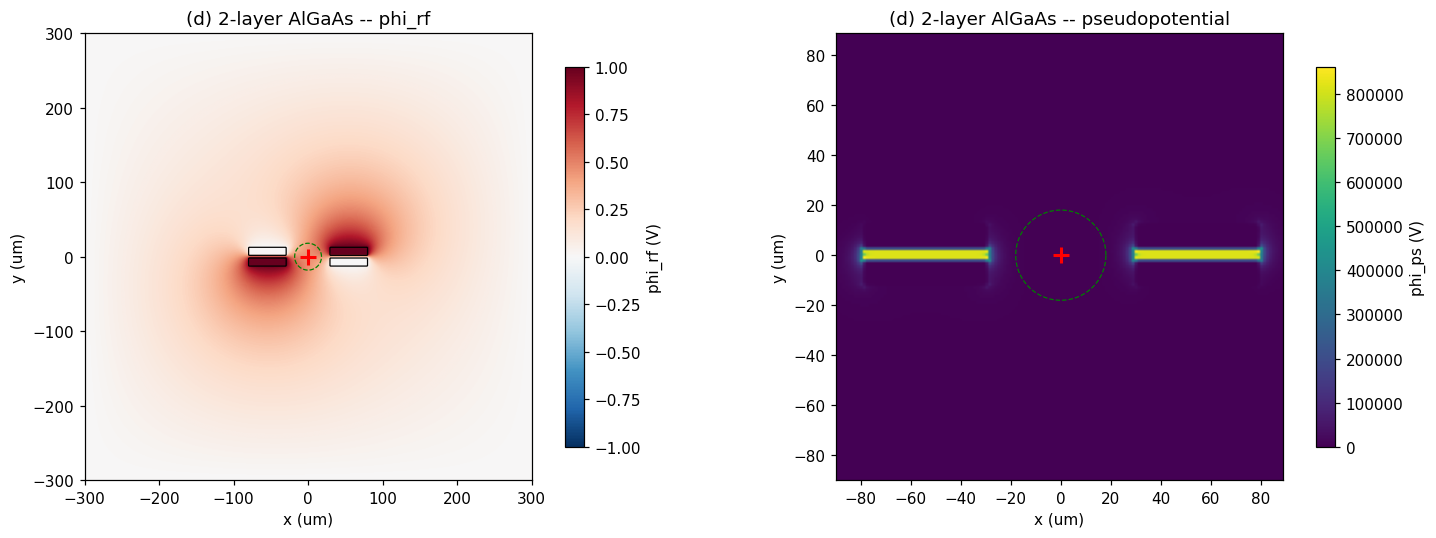

  done (5.5 s)

  (e) In-plane 4-wire
  grid 501x501  domain +/-600 um  dx=2.40 um
  Laplace solved in 3.9 s
  RF null at (-0.00, -0.00)  |grad|=3.304e-08
  R=40.00 um   r_fit=24.00 um
  phi_rf  p2=1.2850e-01
    p3/p2 = 0.0000
    p4/p2 = 0.2688
    p5/p2 = 0.0000
    p6/p2 = 0.0826
    p7/p2 = 0.0000
    p8/p2 = 0.0155
  phi_ps  p2=3.1216e+02
    p3/p2 = 0.0000
    p4/p2 = 0.4658
    p5/p2 = 0.0000
    p6/p2 = 0.1165
    p7/p2 = 0.0000
    p8/p2 = 0.1316


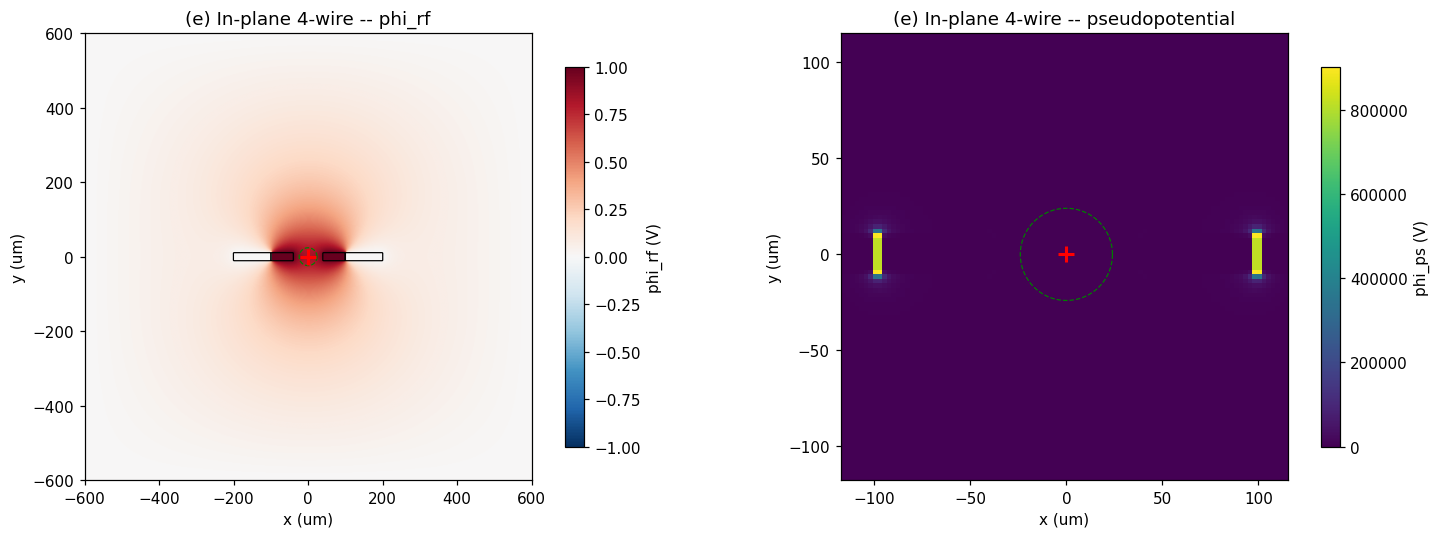

  done (6.1 s)

  (f) 4-wire surface
  grid 501x501  domain +/-438 um  dx=1.75 um
  Laplace solved in 3.7 s
  RF null at (-41.36, 6.35)  |grad|=-5.780e-03
  R=5.25 um   r_fit=5.25 um
  phi_rf  p2=3.3717e-02
    p3/p2 = 0.8231
    p4/p2 = 0.2654
    p5/p2 = 0.2216
    p6/p2 = 0.1146
    p7/p2 = 0.1448
    p8/p2 = 0.0643
  phi_ps  p2=2.7049e+04
    p3/p2 = 0.2155
    p4/p2 = 0.3625
    p5/p2 = 0.2851
    p6/p2 = 0.1983
    p7/p2 = 0.1341
    p8/p2 = 0.0474


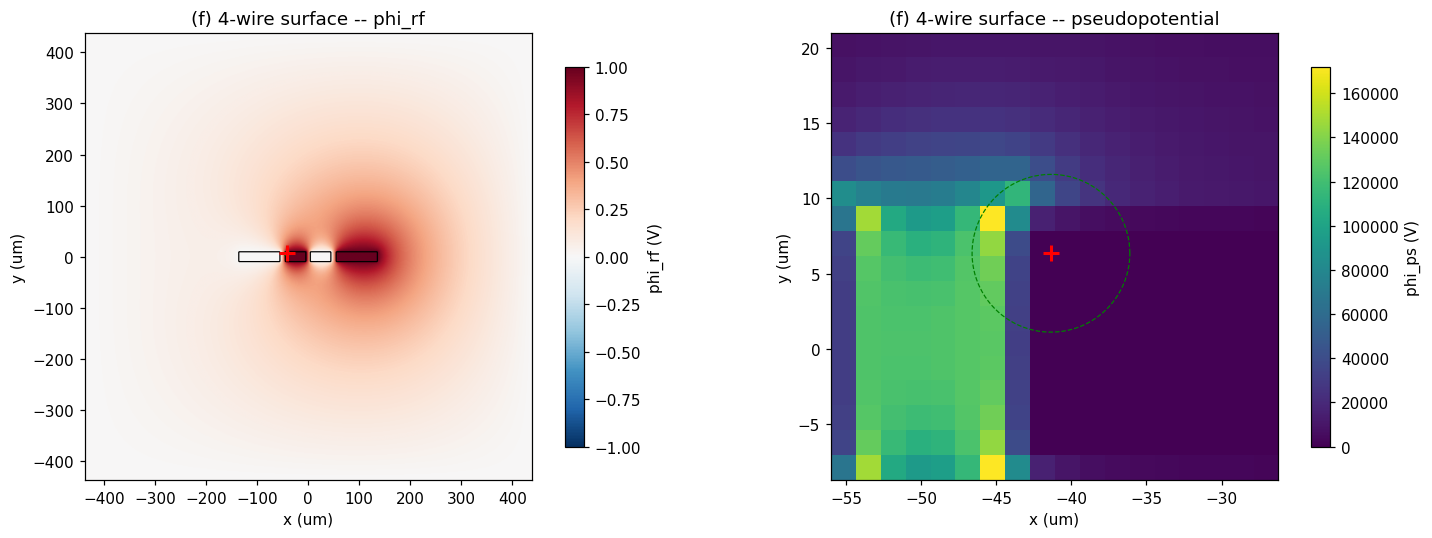

  done (5.8 s)

  (g) 5-wire symm. surface
  grid 501x501  domain +/-500 um  dx=2.00 um
  Laplace solved in 3.6 s
  RF null at (-0.00, 52.64)  |grad|=9.447e-05
  R=42.64 um   r_fit=25.59 um
  phi_rf  p2=1.3798e-01
    p3/p2 = 0.9774
    p4/p2 = 0.6010
    p5/p2 = 0.2367
    p6/p2 = 0.0006
    p7/p2 = 0.1133
    p8/p2 = 0.1430
  phi_ps  p2=8.6388e+02
    p3/p2 = 0.3533
    p4/p2 = 0.1929
    p5/p2 = 0.5237
    p6/p2 = 0.6371
    p7/p2 = 0.5785
    p8/p2 = 0.4100


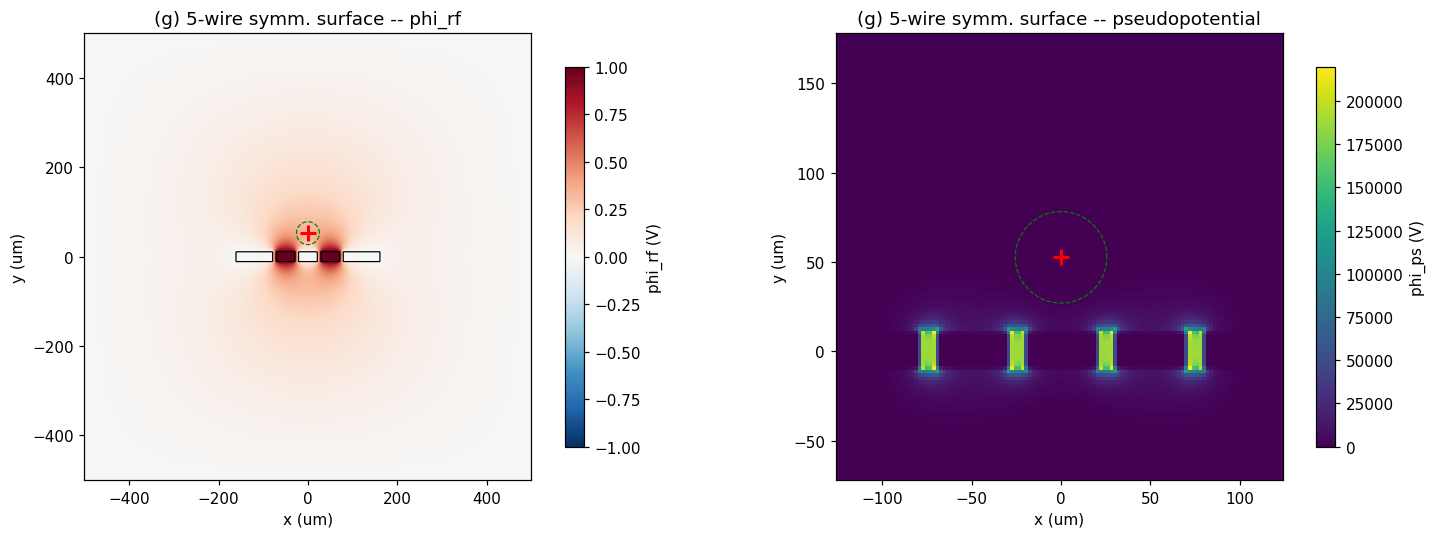

  done (5.7 s)

  (h) 5-wire asymm. surface
  grid 501x501  domain +/-500 um  dx=2.00 um
  Laplace solved in 3.6 s
  RF null at (5.98, 52.46)  |grad|=8.365e-05
  R=42.46 um   r_fit=25.48 um
  phi_rf  p2=1.3785e-01
    p3/p2 = 0.9761
    p4/p2 = 0.6001
    p5/p2 = 0.2387
    p6/p2 = 0.0400
    p7/p2 = 0.1183
    p8/p2 = 0.1446
  phi_ps  p2=8.7320e+02
    p3/p2 = 0.3738
    p4/p2 = 0.2350
    p5/p2 = 0.5345
    p6/p2 = 0.6393
    p7/p2 = 0.5777
    p8/p2 = 0.4117


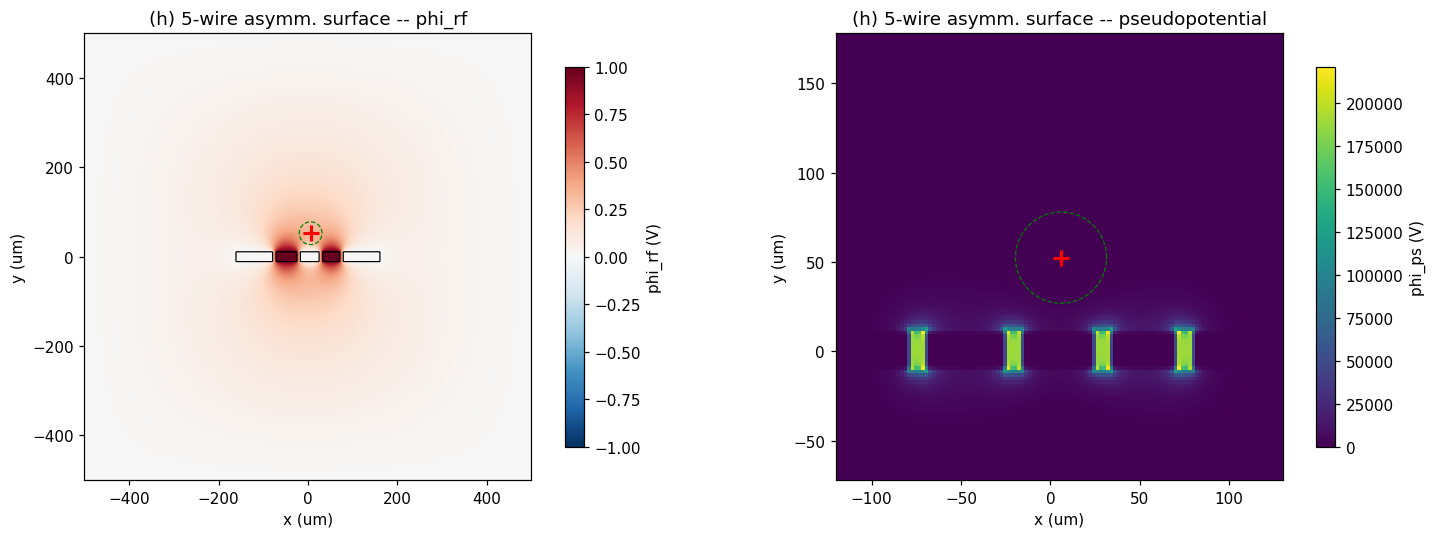

  done (5.7 s)

All simulations complete.


In [7]:
# ============================================================
# Cell 5 -- Run all 8 traps
# ============================================================

CONFIGS = [
    (trap_a_2layer,       '(a) 2-layer',              2.0),
    (trap_b_balanced,     '(b) Balanced 2-layer',     2.0),
    (trap_c_3layer,       '(c) 3-layer',              3.0),
    (trap_d_algaas,       '(d) 2-layer AlGaAs',       2.5),
    (trap_e_inplane4,     '(e) In-plane 4-wire',      2.5),
    (trap_f_4wire_surface,'(f) 4-wire surface',       2.5),
    (trap_g_5wire_symm,   '(g) 5-wire symm. surface', 2.5),
    (trap_h_5wire_asymm,  '(h) 5-wire asymm. surface',2.5),
]

GRID = 501

all_results = {}
for builder, name, scale in CONFIGS:
    try:
        all_results[name] = simulate_trap(builder, name,
                                          grid=GRID, dom_scale=scale,
                                          plot=True)
    except Exception as exc:
        import traceback; traceback.print_exc()
        nan = {f'p{n}/p2': np.nan for n in range(3, 9)}
        all_results[name] = {'rf_ratios': nan, 'ps_ratios': nan}

print('\n' + '='*60 + '\nAll simulations complete.\n' + '='*60)

In [8]:
# ============================================================
# Cell 6 -- Comparison tables
# ============================================================

cols = [f'p{n}/p2' for n in range(3, 9)]

rf_df = pd.DataFrame({n: r['rf_ratios'] for n, r in all_results.items()}).T.reindex(columns=cols)
ps_df = pd.DataFrame({n: r['ps_ratios'] for n, r in all_results.items()}).T.reindex(columns=cols)

# Reference (Table 3.2)
ref = {
    '(a) 2-layer':              {'p3/p2':0.0015,'p4/p2':0.0284,'p5/p2':0.0005,'p6/p2':0.1171,'p7/p2':0.0036,'p8/p2':0.0039},
    '(b) Balanced 2-layer':     {'p3/p2':0.0011,'p4/p2':0.0158,'p5/p2':0.0009,'p6/p2':0.1156,'p7/p2':0.0005,'p8/p2':0.0242},
    '(c) 3-layer':              {'p3/p2':0.0006,'p4/p2':0.1904,'p5/p2':0.0006,'p6/p2':0.0554,'p7/p2':0.0005,'p8/p2':0.0203},
    '(d) 2-layer AlGaAs':       {'p3/p2':0.0026,'p4/p2':0.6005,'p5/p2':0.0054,'p6/p2':0.4340,'p7/p2':0.0143,'p8/p2':0.2642},
    '(e) In-plane 4-wire':      {'p3/p2':0.0008,'p4/p2':0.3443,'p5/p2':0.0009,'p6/p2':0.1191,'p7/p2':0.0010,'p8/p2':0.0330},
    '(f) 4-wire surface':       {'p3/p2':0.9731,'p4/p2':0.6931,'p5/p2':0.4255,'p6/p2':0.2442,'p7/p2':0.1481,'p8/p2':0.1074},
    '(g) 5-wire symm. surface': {'p3/p2':0.9963,'p4/p2':0.6202,'p5/p2':0.2640,'p6/p2':0.0408,'p7/p2':0.1504,'p8/p2':0.1426},
    '(h) 5-wire asymm. surface':{'p3/p2':1.0100,'p4/p2':0.6401,'p5/p2':0.2737,'p6/p2':0.0569,'p7/p2':0.1195,'p8/p2':0.1455},
}
ref_df = pd.DataFrame(ref).T.reindex(columns=cols)

fmt = lambda x: f'{x:.4f}'

print('\n' + '='*80)
print('  SIMULATED  phi_rf  MULTIPOLE RATIOS')
print('='*80)
print(rf_df.to_string(float_format=fmt))

print('\n' + '='*80)
print('  REFERENCE  (Table 3.2)')
print('='*80)
print(ref_df.to_string(float_format=fmt))

print('\n' + '='*80)
print('  |sim_rf - ref|  ABSOLUTE DIFFERENCE')
print('='*80)
print((rf_df - ref_df).abs().to_string(float_format=fmt))

print('\n' + '='*80)
print('  SIMULATED  phi_ps  (PSEUDOPOTENTIAL)  MULTIPOLE RATIOS')
print('  Note: For symmetric traps (a)-(e) the pseudopotential is nearly')
print('  radially symmetric at the origin, so p2 ~ 0 and ratios are N/A.')
print('  Pseudopotential multipoles are most meaningful for surface traps.')
print('='*80)
print(ps_df.to_string(float_format=fmt))

# save
rf_df.to_csv('csv/sim_rf_ratios.csv')
ps_df.to_csv('csv/sim_ps_ratios.csv')
ref_df.to_csv('csv/ref_ratios.csv')
print('\nCSVs saved: csv/sim_rf_ratios.csv, csv/sim_ps_ratios.csv, csv/ref_ratios.csv')


  SIMULATED  phi_rf  MULTIPOLE RATIOS
                           p3/p2  p4/p2  p5/p2  p6/p2  p7/p2  p8/p2
(a) 2-layer               0.0000 0.0018 0.0000 0.1028 0.0000 0.0005
(b) Balanced 2-layer      0.0000 0.0413 0.0000 0.0982 0.0000 0.0191
(c) 3-layer               0.0000 0.1202 0.0000 0.0338 0.0000 0.0109
(d) 2-layer AlGaAs        0.0000 0.6225 0.0000 0.4225 0.0000 0.2954
(e) In-plane 4-wire       0.0000 0.2688 0.0000 0.0826 0.0000 0.0155
(f) 4-wire surface        0.8231 0.2654 0.2216 0.1146 0.1448 0.0643
(g) 5-wire symm. surface  0.9774 0.6010 0.2367 0.0006 0.1133 0.1430
(h) 5-wire asymm. surface 0.9761 0.6001 0.2387 0.0400 0.1183 0.1446

  REFERENCE  (Table 3.2)
                           p3/p2  p4/p2  p5/p2  p6/p2  p7/p2  p8/p2
(a) 2-layer               0.0015 0.0284 0.0005 0.1171 0.0036 0.0039
(b) Balanced 2-layer      0.0011 0.0158 0.0009 0.1156 0.0005 0.0242
(c) 3-layer               0.0006 0.1904 0.0006 0.0554 0.0005 0.0203
(d) 2-layer AlGaAs        0.0026 0.6005 0.0054 0.43

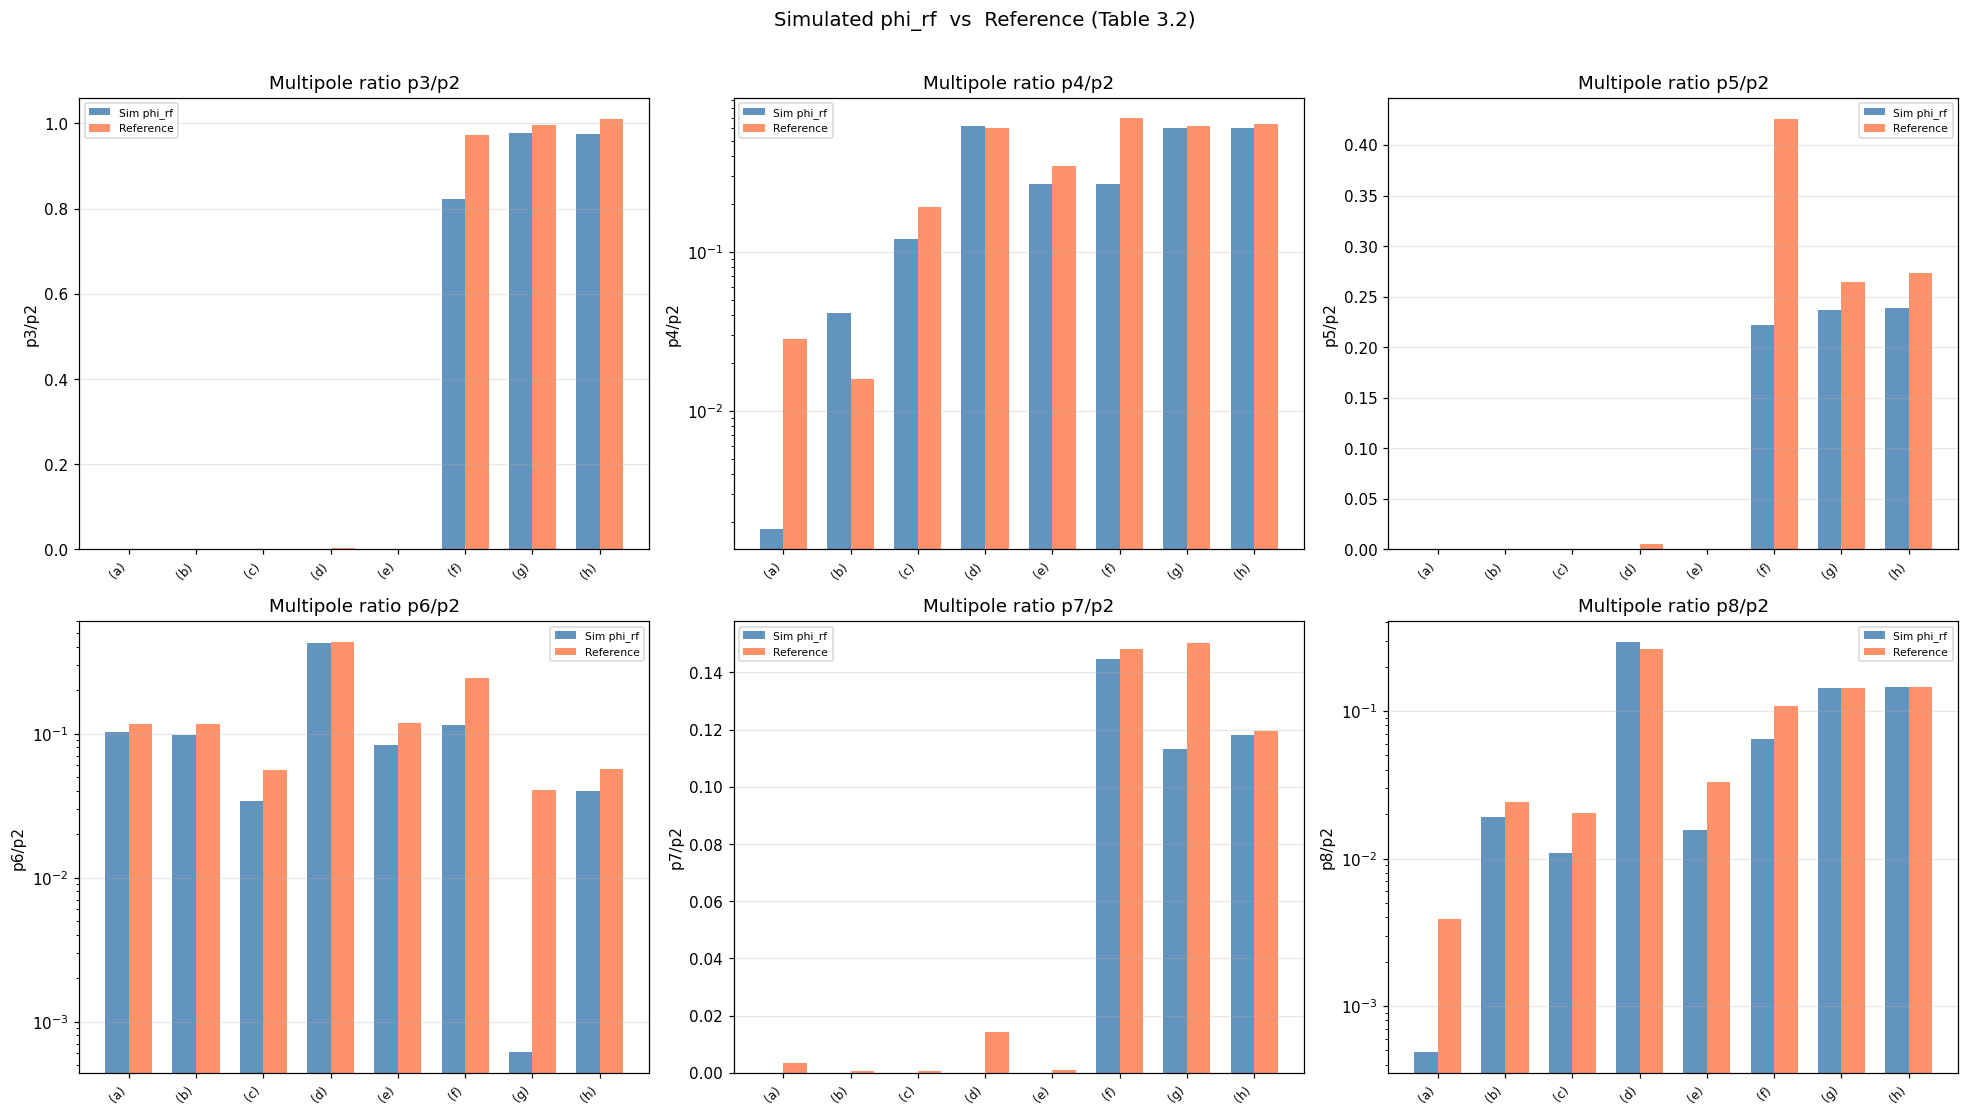

Saved multipole_comparison.png


In [9]:
# ============================================================
# Cell 7 -- Bar-chart comparison
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, n in enumerate(range(3, 9)):
    ax  = axes.flat[idx]
    col = f'p{n}/p2'
    x   = np.arange(len(rf_df))
    w   = 0.35

    ax.bar(x - w/2, rf_df[col].values, w, label='Sim phi_rf', alpha=0.85, color='steelblue')
    ax.bar(x + w/2, ref_df[col].values, w, label='Reference',  alpha=0.85, color='coral')

    ax.set_ylabel(col)
    ax.set_title(f'Multipole ratio {col}')
    ax.set_xticks(x)
    ax.set_xticklabels([s.split(')')[0]+')' for s in rf_df.index],
                       rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)
    if n in (4, 6, 8):
        ax.set_yscale('log')

plt.suptitle('Simulated phi_rf  vs  Reference (Table 3.2)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('pngs/multipole_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved pngs/multipole_comparison.png')

## Whiteboard Electrode Geometries

Two blade-trap cross-sections from the whiteboard sketch:

1. **U-channel (opening up)** — Two RF blades facing each other with ground wings flaring outward at the top and a ground base connecting the bottom.
2. **Inverted (180° rotation)** — Same structure flipped vertically: wings at the bottom, base at the top.

Orange regions = RF electrodes ($V = +1\,$V), blue structure = ground ($V = 0\,$V).


  Blade Trap — U-channel (opening up)
  grid 501x501  domain +/-330 um  dx=1.32 um
  Laplace solved in 2.4 s
  ion at origin   R=60.00 um   r_fit=36.00 um
  phi_rf  p2 = 2.3392e-01
    p3/p2 = 0.0711
    p4/p2 = 0.1131
    p5/p2 = 0.0074
    p6/p2 = 0.0428
    p7/p2 = 0.0002
    p8/p2 = 0.0114
  phi_ps  p2 = 2.0621e+02
    p3/p2 = 0.2798
    p4/p2 = 0.5024
    p5/p2 = 0.1382
    p6/p2 = 0.1836
    p7/p2 = 0.0468
    p8/p2 = 0.0505


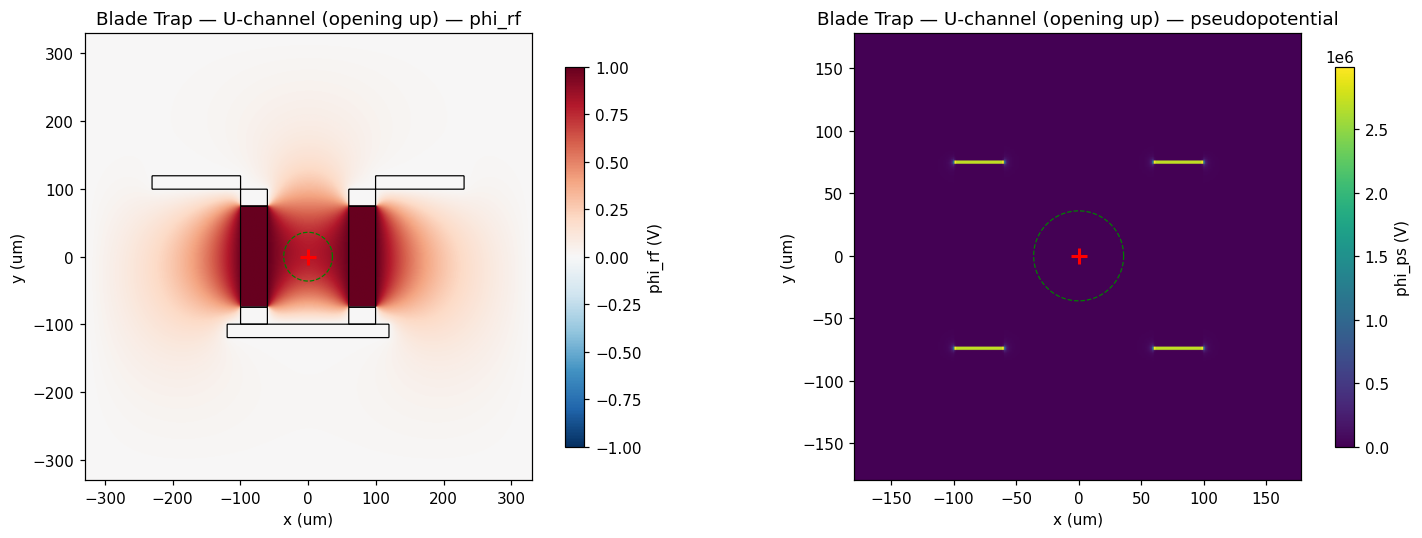

  done (4.1 s)


In [10]:
# ============================================================
# Whiteboard Geometry 1: Blade Trap — U-channel (opening up)
# ============================================================
# Two RF blades facing each other, ground wings at top,
# ground base at bottom.  Ion trapped at centre by symmetry.

def trap_blade_up():
    gap = 120       # inter-electrode gap between RF inner faces (um)
    rf_w = 40       # RF electrode width
    rf_h = 150      # RF electrode height
    wing_l = 130    # wing horizontal extent (outward from wall edge)
    wing_t = 20     # wing thickness
    base_t = 20     # base thickness
    wall_ext = 25   # ground wall extension above/below RF

    x_rf = gap / 2 + rf_w / 2
    y_top_wall = rf_h / 2 + wall_ext / 2
    y_bot_wall = -(rf_h / 2 + wall_ext / 2)
    y_wing = rf_h / 2 + wall_ext + wing_t / 2
    y_base = -(rf_h / 2 + wall_ext + base_t / 2)
    x_wing = gap / 2 + rf_w + wing_l / 2
    base_w = gap + 2 * rf_w + 40

    return [
        {'cx': -x_rf, 'cy': 0,          'w': rf_w,   'h': rf_h,     'V': 1.0, 'label': 'RF-L'},
        {'cx':  x_rf, 'cy': 0,          'w': rf_w,   'h': rf_h,     'V': 1.0, 'label': 'RF-R'},
        {'cx': -x_rf, 'cy': y_top_wall, 'w': rf_w,   'h': wall_ext, 'V': 0.0, 'label': 'Wall-TL'},
        {'cx':  x_rf, 'cy': y_top_wall, 'w': rf_w,   'h': wall_ext, 'V': 0.0, 'label': 'Wall-TR'},
        {'cx': -x_rf, 'cy': y_bot_wall, 'w': rf_w,   'h': wall_ext, 'V': 0.0, 'label': 'Wall-BL'},
        {'cx':  x_rf, 'cy': y_bot_wall, 'w': rf_w,   'h': wall_ext, 'V': 0.0, 'label': 'Wall-BR'},
        {'cx': -x_wing, 'cy': y_wing,   'w': wing_l, 'h': wing_t,   'V': 0.0, 'label': 'Wing-L'},
        {'cx':  x_wing, 'cy': y_wing,   'w': wing_l, 'h': wing_t,   'V': 0.0, 'label': 'Wing-R'},
        {'cx': 0,        'cy': y_base,   'w': base_w, 'h': base_t,   'V': 0.0, 'label': 'Base'},
    ], 0.0


# --- run simulation ---
t0 = time.time()
name = 'Blade Trap — U-channel (opening up)'
print(f'\n{"="*60}\n  {name}\n{"="*60}')

elecs_up, _ = trap_blade_up()
max_x = max(abs(e['cx']) + e['w'] / 2 for e in elecs_up)
max_y = max(abs(e['cy']) + e['h'] / 2 for e in elecs_up)
ds = max(max_x, max_y) + 100

nx = ny = 501
x = np.linspace(-ds, ds, nx)
y = np.linspace(-ds, ds, ny)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]
print(f'  grid {nx}x{ny}  domain +/-{ds:.0f} um  dx={dx:.2f} um')

V_rf_up, elecs_up, fixed_up = solve_laplace(nx, ny, elecs_up, X, Y)
print(f'  Laplace solved in {time.time()-t0:.1f} s')

ix, iy = 0.0, 0.0
R = ion_electrode_dist(elecs_up, ix, iy)
r_fit = max(R * 0.6, 3 * dx)
R = max(R, r_fit)
print(f'  ion at origin   R={R:.2f} um   r_fit={r_fit:.2f} um')

rf_p = fit_multipoles(V_rf_up, X, Y, ix, iy, r_fit, R)
rf_rat = ratio_row(rf_p)
print(f'  phi_rf  p2 = {rf_p[2]:.4e}')
for k, v in rf_rat.items():
    print(f'    {k} = {v:.4f}')

phi_ps_up = pseudopotential(V_rf_up, X, Y)
ps_p = fit_multipoles(phi_ps_up, X, Y, ix, iy, r_fit, R)
ps_rat = ratio_row(ps_p)
print(f'  phi_ps  p2 = {ps_p[2]:.4e}')
for k, v in ps_rat.items():
    print(f'    {k} = {v:.4f}')

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
th = np.linspace(0, 2 * np.pi, 200)

ax = axes[0]
vm = max(abs(V_rf_up.min()), abs(V_rf_up.max()))
im = ax.imshow(V_rf_up, extent=[x[0], x[-1], y[0], y[-1]],
               origin='lower', cmap='RdBu_r', vmin=-vm, vmax=vm)
fig.colorbar(im, ax=ax, label='phi_rf (V)', shrink=0.85)
for e in elecs_up:
    ax.contour(X, Y, e['mask'].astype(float), [0.5], colors='k', linewidths=0.8)
ax.plot(ix + r_fit * np.cos(th), iy + r_fit * np.sin(th), 'g--', lw=0.8)
ax.plot(ix, iy, 'r+', ms=10, mew=2)
ax.set(title=f'{name} — phi_rf', xlabel='x (um)', ylabel='y (um)', aspect='equal')

ax = axes[1]
zoom = R * 3
xi_idx = np.searchsorted(x, ix)
yi_idx = np.searchsorted(y, iy)
mp = int(zoom / dx)
s = np.s_[max(0, yi_idx - mp):min(ny, yi_idx + mp),
          max(0, xi_idx - mp):min(nx, xi_idx + mp)]
ps_z = phi_ps_up[s]
ext = [X[0, max(0, s[1].start)], X[0, min(s[1].stop, nx) - 1],
       Y[max(0, s[0].start), 0], Y[min(s[0].stop, ny) - 1, 0]]
im2 = ax.imshow(ps_z, extent=ext, origin='lower', cmap='viridis')
fig.colorbar(im2, ax=ax, label='phi_ps (V)', shrink=0.85)
ax.plot(ix, iy, 'r+', ms=10, mew=2)
ax.plot(ix + r_fit * np.cos(th), iy + r_fit * np.sin(th), 'g--', lw=0.8)
ax.set(title=f'{name} — pseudopotential', xlabel='x (um)', ylabel='y (um)', aspect='equal')

plt.tight_layout()
plt.show()
print(f'  done ({time.time()-t0:.1f} s)')


  Blade Trap — Inverted 180° (opening down)
  grid 501x501  domain +/-330 um  dx=1.32 um
  Laplace solved in 2.4 s
  ion at origin   R=60.00 um   r_fit=36.00 um
  phi_rf  p2 = 2.3392e-01
    p3/p2 = 0.0711
    p4/p2 = 0.1131
    p5/p2 = 0.0074
    p6/p2 = 0.0428
    p7/p2 = 0.0002
    p8/p2 = 0.0114
  phi_ps  p2 = 2.0621e+02
    p3/p2 = 0.2798
    p4/p2 = 0.5024
    p5/p2 = 0.1382
    p6/p2 = 0.1836
    p7/p2 = 0.0468
    p8/p2 = 0.0505


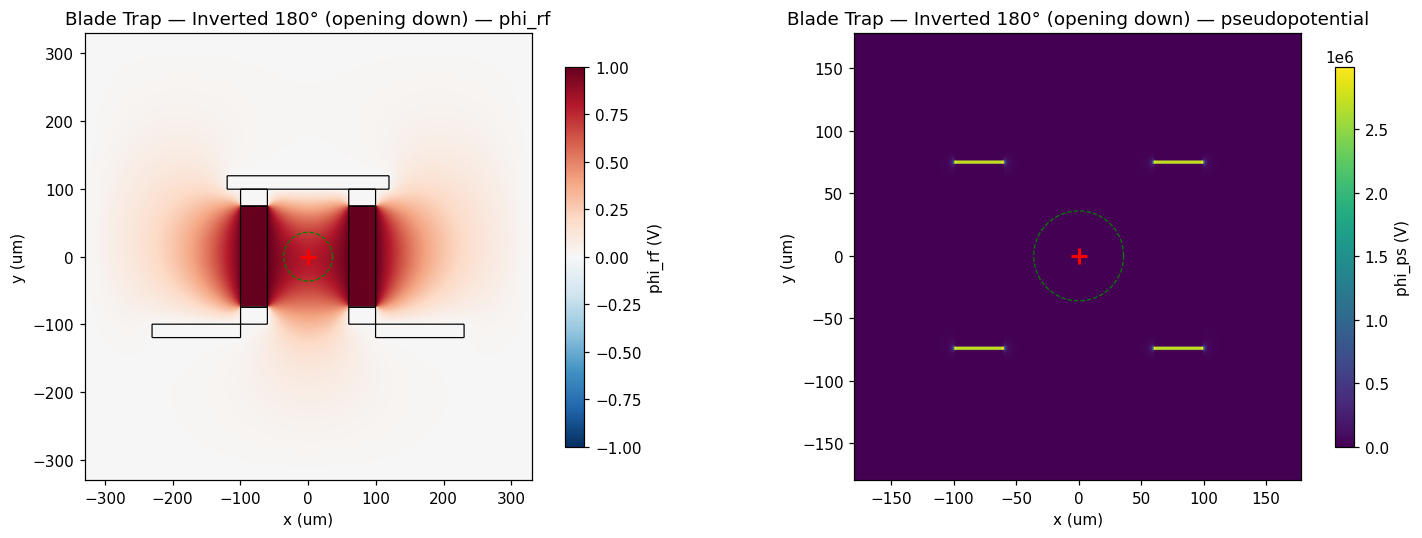

  done (4.2 s)

  Comparison: opening-up vs inverted (180°)
  Since the 180° rotation is a vertical mirror, even-order
  multipole ratios should match and odd-order phase flips
  (amplitudes identical).


In [11]:
# ============================================================
# Whiteboard Geometry 2: Blade Trap — Inverted (180° rotation)
# ============================================================
# Same blade-trap cross-section rotated 180°:
# ground wings at bottom, ground base at top.

def trap_blade_down():
    gap = 120
    rf_w = 40
    rf_h = 150
    wing_l = 130
    wing_t = 20
    base_t = 20
    wall_ext = 25

    x_rf = gap / 2 + rf_w / 2
    y_top_wall = rf_h / 2 + wall_ext / 2
    y_bot_wall = -(rf_h / 2 + wall_ext / 2)
    y_wing = -(rf_h / 2 + wall_ext + wing_t / 2)   # wings now at BOTTOM
    y_base = rf_h / 2 + wall_ext + base_t / 2       # base now at TOP
    x_wing = gap / 2 + rf_w + wing_l / 2
    base_w = gap + 2 * rf_w + 40

    return [
        {'cx': -x_rf, 'cy': 0,          'w': rf_w,   'h': rf_h,     'V': 1.0, 'label': 'RF-L'},
        {'cx':  x_rf, 'cy': 0,          'w': rf_w,   'h': rf_h,     'V': 1.0, 'label': 'RF-R'},
        {'cx': -x_rf, 'cy': y_top_wall, 'w': rf_w,   'h': wall_ext, 'V': 0.0, 'label': 'Wall-TL'},
        {'cx':  x_rf, 'cy': y_top_wall, 'w': rf_w,   'h': wall_ext, 'V': 0.0, 'label': 'Wall-TR'},
        {'cx': -x_rf, 'cy': y_bot_wall, 'w': rf_w,   'h': wall_ext, 'V': 0.0, 'label': 'Wall-BL'},
        {'cx':  x_rf, 'cy': y_bot_wall, 'w': rf_w,   'h': wall_ext, 'V': 0.0, 'label': 'Wall-BR'},
        {'cx': -x_wing, 'cy': y_wing,   'w': wing_l, 'h': wing_t,   'V': 0.0, 'label': 'Wing-L'},
        {'cx':  x_wing, 'cy': y_wing,   'w': wing_l, 'h': wing_t,   'V': 0.0, 'label': 'Wing-R'},
        {'cx': 0,        'cy': y_base,   'w': base_w, 'h': base_t,   'V': 0.0, 'label': 'Base'},
    ], 0.0


# --- run simulation ---
t0 = time.time()
name = 'Blade Trap — Inverted 180° (opening down)'
print(f'\n{"="*60}\n  {name}\n{"="*60}')

elecs_dn, _ = trap_blade_down()
max_x = max(abs(e['cx']) + e['w'] / 2 for e in elecs_dn)
max_y = max(abs(e['cy']) + e['h'] / 2 for e in elecs_dn)
ds = max(max_x, max_y) + 100

nx = ny = 501
x = np.linspace(-ds, ds, nx)
y = np.linspace(-ds, ds, ny)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]
print(f'  grid {nx}x{ny}  domain +/-{ds:.0f} um  dx={dx:.2f} um')

V_rf_dn, elecs_dn, fixed_dn = solve_laplace(nx, ny, elecs_dn, X, Y)
print(f'  Laplace solved in {time.time()-t0:.1f} s')

ix, iy = 0.0, 0.0
R = ion_electrode_dist(elecs_dn, ix, iy)
r_fit = max(R * 0.6, 3 * dx)
R = max(R, r_fit)
print(f'  ion at origin   R={R:.2f} um   r_fit={r_fit:.2f} um')

rf_p = fit_multipoles(V_rf_dn, X, Y, ix, iy, r_fit, R)
rf_rat = ratio_row(rf_p)
print(f'  phi_rf  p2 = {rf_p[2]:.4e}')
for k, v in rf_rat.items():
    print(f'    {k} = {v:.4f}')

phi_ps_dn = pseudopotential(V_rf_dn, X, Y)
ps_p = fit_multipoles(phi_ps_dn, X, Y, ix, iy, r_fit, R)
ps_rat = ratio_row(ps_p)
print(f'  phi_ps  p2 = {ps_p[2]:.4e}')
for k, v in ps_rat.items():
    print(f'    {k} = {v:.4f}')

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
th = np.linspace(0, 2 * np.pi, 200)

ax = axes[0]
vm = max(abs(V_rf_dn.min()), abs(V_rf_dn.max()))
im = ax.imshow(V_rf_dn, extent=[x[0], x[-1], y[0], y[-1]],
               origin='lower', cmap='RdBu_r', vmin=-vm, vmax=vm)
fig.colorbar(im, ax=ax, label='phi_rf (V)', shrink=0.85)
for e in elecs_dn:
    ax.contour(X, Y, e['mask'].astype(float), [0.5], colors='k', linewidths=0.8)
ax.plot(ix + r_fit * np.cos(th), iy + r_fit * np.sin(th), 'g--', lw=0.8)
ax.plot(ix, iy, 'r+', ms=10, mew=2)
ax.set(title=f'{name} — phi_rf', xlabel='x (um)', ylabel='y (um)', aspect='equal')

ax = axes[1]
zoom = R * 3
xi_idx = np.searchsorted(x, ix)
yi_idx = np.searchsorted(y, iy)
mp = int(zoom / dx)
s = np.s_[max(0, yi_idx - mp):min(ny, yi_idx + mp),
          max(0, xi_idx - mp):min(nx, xi_idx + mp)]
ps_z = phi_ps_dn[s]
ext = [X[0, max(0, s[1].start)], X[0, min(s[1].stop, nx) - 1],
       Y[max(0, s[0].start), 0], Y[min(s[0].stop, ny) - 1, 0]]
im2 = ax.imshow(ps_z, extent=ext, origin='lower', cmap='viridis')
fig.colorbar(im2, ax=ax, label='phi_ps (V)', shrink=0.85)
ax.plot(ix, iy, 'r+', ms=10, mew=2)
ax.plot(ix + r_fit * np.cos(th), iy + r_fit * np.sin(th), 'g--', lw=0.8)
ax.set(title=f'{name} — pseudopotential', xlabel='x (um)', ylabel='y (um)', aspect='equal')

plt.tight_layout()
plt.show()
print(f'  done ({time.time()-t0:.1f} s)')

# --- compare the two geometries ---
print(f'\n{"="*60}')
print('  Comparison: opening-up vs inverted (180°)')
print(f'{"="*60}')
print('  Since the 180° rotation is a vertical mirror, even-order')
print('  multipole ratios should match and odd-order phase flips')
print('  (amplitudes identical).')